# Class 15: First-order Differential Equation 

Ch. 8, section 1: Euler & Runge-Kutta

- Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Euler's Method  
#### Example 8.1

Solve the differential equation: 
$$ \frac{dx}{dt} = -x^3 +\sin t$$
with initial conditions $x=0$ at $t=0$. 

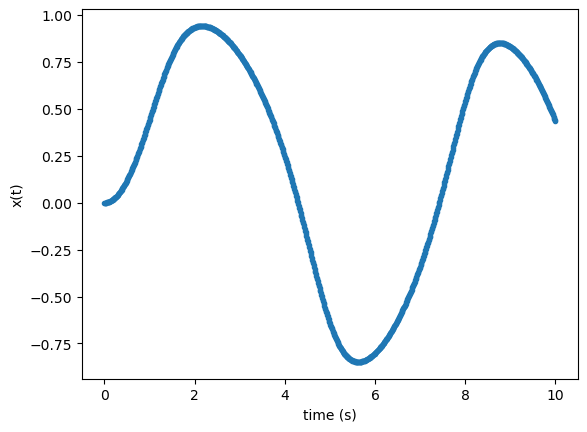

In [2]:
# define function f(x,t)
def f(x,t): 
    return -x**3 + np.sin(t)

# define initial conditons/constants
a = 0.0 # starting time 
b = 10.0 # end of time interval 
N = 1000 # number of steps between a and b
h = (b - a)/N
x = 0.0

# define position and time arrays 
tpts = np.arange(a,b+h,h)
xpts = np.zeros(len(tpts))

# apply Euler's method 
for i in range(len(tpts)): 
    xpts[i] = x
    x += h*f(x,tpts[i])

# plot the results 
plt.plot(tpts,xpts,".")
plt.xlabel("time (s)")
plt.ylabel("x(t)")
plt.show()

#### Radioactive decay

$$\frac{dN}{dt} = -kN $$

Determine the solution fo $N(t)$ given that the number of atoms to start $N_0$ is 1000, and the decay constant $k = 0.05$

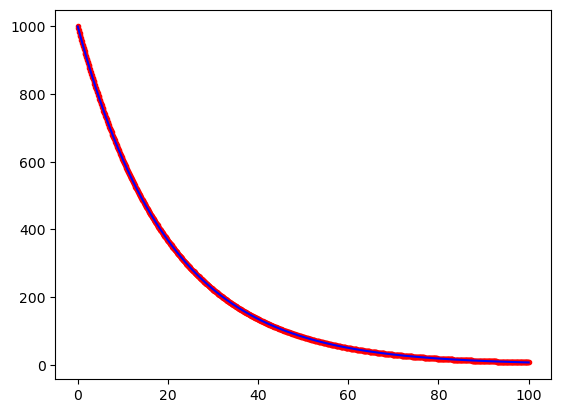

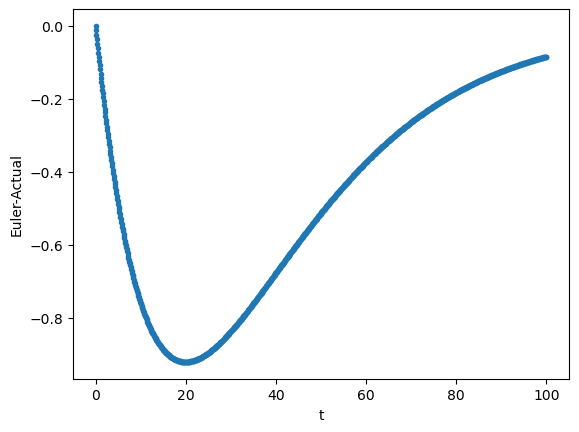

In [14]:
# define function f(N,t,k)
def f(N,t,k):
    return -k*N

# constants & initial conditions 
k = 0.05
N0 = 1000
tstart = 0.0 # equivalent of a
tend = 100.0 # equivalent of b
Nsteps = 1000 # number of steps between tstart and tend 
h = (tend-tstart)/Nsteps

# define position and time arrays 
tpts = np.arange(tstart,tend+h,h)
Npts = np.zeros(len(tpts))

# apply Euler's method 
for i in range(len(tpts)): 
    Npts[i] = N0
    N0 += h*f(N0,tpts[i], k)

# actual results 
Nactual = 1000*np.exp(-k*tpts)

plt.plot(tpts, Npts, ".r")
plt.plot(tpts, Nactual, "b")
plt.show()

# compare the difference 
plt.figure(2)
plt.plot(tpts,Npts-Nactual,".")
plt.xlabel("t")
plt.ylabel("Euler-Actual")
plt.show()



## Second-Order Runge-Kutta

Apply the second-order Runge-Kutta method to solve example 8.1 as done above with Euler's method

Solve the differential equation: 
$$ \frac{dx}{dt} = -x^3 +\sin t$$
with initial conditions $x=0$ at $t=0$. 


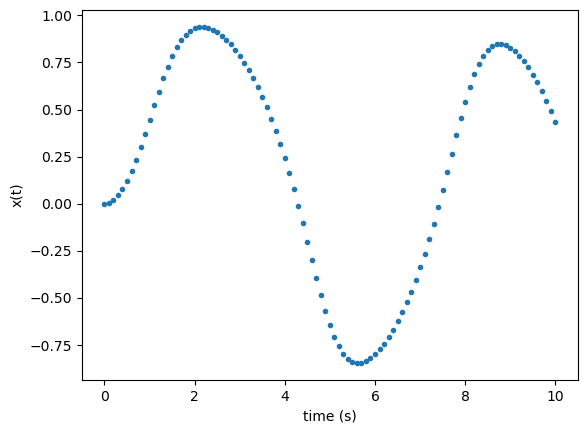

In [7]:
# define function 
def f(x,t):
    return -x**3 + np.sin(t)

# define inital conditions + constants 
a = 0.0 # starting time 
b = 10.0 # endign time 
N = 100 # steps 
h = (b-a)/N
# initial condition 
x = 0.0

# define position and time arrays 
tpts = np.arange(a,b+h,h)
xpts = np.zeros(len(tpts))

# apply second order Runge-Kutta method 
for i in range(len(tpts)):
    xpts[i] = x
    k1 = h*f(x,tpts[i])
    k2 = h*f(x+0.5*k1,tpts[i]+0.5*h)
    x += k2

# plot the results 
plt.plot(tpts,xpts,".")
plt.xlabel("time (s)")
plt.ylabel("x(t)")
plt.show()

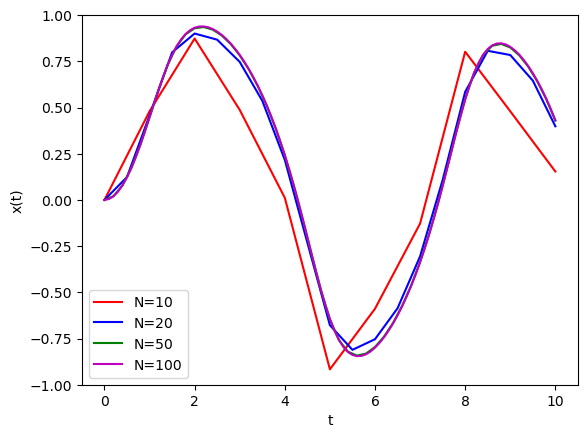

In [8]:
# book problem to solve same differential equation as Euler above - do again but loop over different N values 

# define function of differential equation
def f(x,t):
    return -x**3 + math.sin(t)

# define constants
a = 0.0 # star of time interval
b = 10.0 # end of time interval
N = [10, 20, 50, 100] #number of steps between a and b use significantly few steps 



# loop through t values to calculate x using second-order runge-kutta 
for j in range(len(N)):
    h = (b-a)/N[j] # step size - make sure is small!
    tpts = np.arange(a,b+h,h)
    xpts = np.zeros(len(tpts))
    # initial conditions + time array  
    x = 0.0 
    for i in range(N[j]+1): 
        xpts[i] = x    
        k1 = h*f(x,tpts[i])
        k2 = h*f(x+0.5*k1,tpts[i]+0.5*h)
        x += k2
    if j == 0:
        x1 = xpts
        t1 = tpts
    if j == 1:
        x2 = xpts
        t2 = tpts
    if j == 2:
        x3 = xpts
        t3 = tpts
    if j == 3:
        x4 = xpts
        t4 = tpts
        
plt.plot(t1,x1,"r") # remove dots to show lines - more informative? 
plt.plot(t2,x2,"b")
plt.plot(t3,x3,"g")
plt.plot(t4,x4,"m")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.ylim(-1,1)
plt.legend(["N=10", "N=20", "N=50", "N=100"])
plt.show()

## Fourth-Order Runge-Kutta

Apply the fourth-order Runge-Kutta method to solve example 8.1 as done above with Euler's method

Solve the differential equation: 
$$ \frac{dx}{dt} = -x^3 +\sin t$$
with initial conditions $x=0$ at $t=0$. 


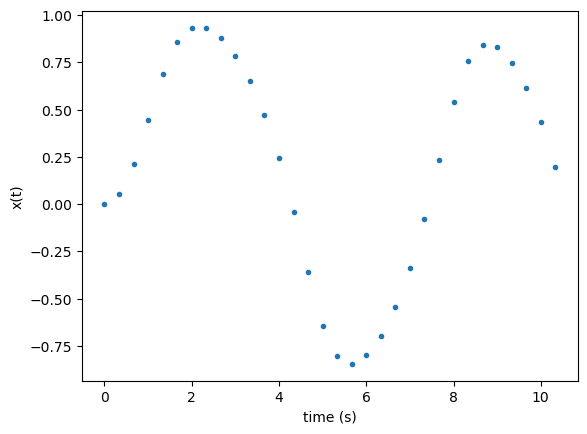

In [11]:
# define function 
def f(x,t):
    return -x**3 + np.sin(t)

# define inital conditions + constants 
a = 0.0 # starting time 
b = 10.0 # endign time 
N = 30 # steps 
h = (b-a)/N
# initial condition 
x = 0.0

# define position and time arrays 
trk4 = np.arange(a,b+h,h)
xrk4 = np.zeros(len(trk4))

# apply second order Runge-Kutta method 
for i in range(len(trk4)):
    xrk4[i] = x
    k1 = h*f(x,trk4[i])
    k2 = h*f(x+0.5*k1,trk4[i]+0.5*h)
    k3 = h*f(x+0.5*k2,trk4[i]+0.5*h)
    k4 = h*f(x+k3, trk4[i]+h)
    x += (k1 + 2*k2 + 2*k3 + k4)/6

# plot the results 
plt.plot(trk4,xrk4, ".")
plt.xlabel("time (s)")
plt.ylabel("x(t)")
plt.show()

#### Radioactive decay - again 

$$\frac{dN}{dt} = -kN $$

Determine the solution for $N(t)$ using fourth-order Runge-Kutta given that the number of atoms to start $N_0$ is 1000, and the decay constant $k = 0.05$

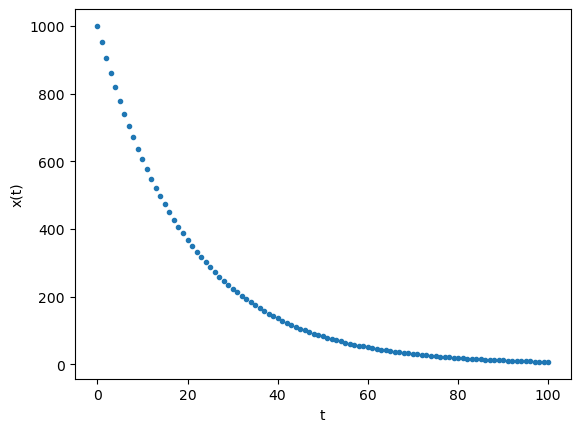

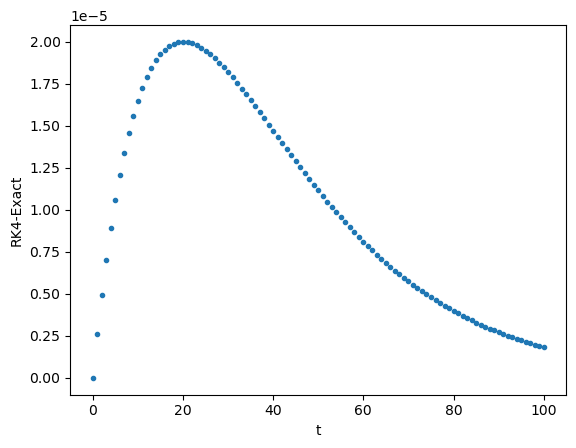

In [12]:
# apply Runge-kutta for radioactive decay 

# define function of differential equation
def f(N,k):
    return -k*N

# define constants 
k = 0.05
# determine steps, boundary conditions, and t array 
tstart = 0.0
tfinal=100.0
Nsteps = 100
h = (tfinal-tstart)/Nsteps

#initial condition
N = 1000

# set up arrays 
tpts = np.arange(tstart,tfinal+h,h)
Npts = np.zeros(len(tpts))

# calculate exact solution to see how differ
NExact = N*np.exp(-k*tpts)

# loop through t values to calculate x using 4th order Runge-Kutta method
for i in range(Nsteps+1): 
    #xrk4[i] = x
    #k1 = h*f(x,trk4[i])
    #k2 = h*f(x+0.5*k1, trk4[i]+0.5*h)
    #k3 = h*f(x+0.5*k2, trk4[i]+0.5*h)
    #k4 = h*f(x+k3, trk4[i]+h)
    #x += (k1 + 2*k2 + 2*k3 + k4)/6
    Npts[i] = N    
    k1 = h*f(N,k)
    k2 = h*f(N+0.5*k1,k)
    k3 = h*f(N+0.5*k2,k)
    k4 = h*f(N+k3,k)
    N += (k1+2*k2+2*k3+k4)/6


plt.figure(1)
plt.plot(tpts,Npts,".")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()



plt.figure(2)
plt.plot(tpts,Npts-NExact,".")
plt.xlabel("t")
plt.ylabel("RK4-Exact")
plt.show()